# FNCE 449 Day 4: Machine Learning Part B -- Decision Trees

## Background

As in the previous lecture, suppose we are trying to predict a a binary outcome: 
   1. a bank loan is "good" (unlikely to default) or "bad" (likely to default). 
   2. a credit card transaction is fraudulent or not;
   3. an e-mail belongs to the junk folder or not.
   
A **decision tree** is a step-by-step process for making predictions. It implies making a decision by looking at features one at a time, rather than all at once in the logistic regression. We first identify, and analyze, the most important feature, then the second, and so forth.

Compared to logistic regression, **decision trees** have a number of advantages:
1. They correspond to the way many human beings think about a problem and are easier to explain to non-specialists. 
2. Do no require that the relationship between the target and the features is linear. 
3. The tree automatically selects the best features to make the prediction. 
4. A decision tree is less sensitive to outlying observations than a regression 

To understand how decision trees work, we go back to the **Lending Club** data we used in the previous lecture. **Lending Club** is a peer-to-peer FinTech platform that allows investors to lend directly to borrowers (no intermediaries). 

We want to estimate the probability of a good loan (i.e., not defaulting) using four features:
 
1. Home ownership (1=yes, 0=no)
2. Annual income (\$)
3. Debt to income ratio (%)
4. Credit score (FICO) 


## Application to Lending Club data

In [20]:
import numpy as np
from pandas import *
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.optimize as spo
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

As before, we take a quick look at a "training" dataset:

In [21]:
path_trainlc='https://github.com/mariuszoican/mgt443/raw/main/Data/lendingclub_traindata.xlsx?raw=true'
lc_data_train=read_excel(path_trainlc)
lc_data_train.head()

,home_ownership,income,dti,fico_low,loan_status
0,1,44.304,18.47,690,0
1,0,38.500,33.73,660,0
2,1,54.000,19.00,660,0
3,1,60.000,33.98,695,0
4,0,39.354,10.85,685,0


In the training data, we have 8695 loans:
1. 1499 "bad" loans that defaulted
2. 7196 good loans that came through

Without knowing anything else, the (unconditional) probability of a good loan is $$\frac{7196}{7196+1499}=82.76\%.$$

How much does learning other information (e.g., whether the applicant owns a home) improve our ability to discriminate between good and bad credit risk? 

To measure such *information gain*, we introduce the notion of **entropy**. Given $n$ outcomes, indexed by $i$, with probability $p_i$, **entropy** can be defined as:

$$\text{Entropy}=-\sum_{i=1}^n p_i \log\left(p_i\right),$$
where the logarithm is base-2. A *lower* entropy corresponds to lower uncertainty -- and therefore, better information.

The entropy from simply observing the success or failure of a loan is:

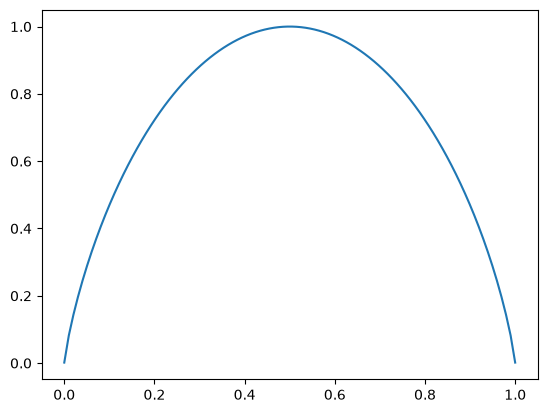

In [22]:
def ent(p):
    return -(p*np.log2(p)+(1-p)*np.log2(1-p))

p_space=np.linspace(0.0001,0.9999,100)
plt.plot(p_space,[ent(pi) for pi in p_space])
plt.show()

In [23]:
prob_unc=[len(lc_data_train[lc_data_train.loan_status==0])/len(lc_data_train),
          len(lc_data_train[lc_data_train.loan_status==1])/len(lc_data_train)]
#-np.sum(prob_unc*np.log2(prob_unc))
prob_unc

[0.17239792984473837, 0.8276020701552617]

In [24]:
# first, we compute unconditional probabilities
prob_unc=[len(lc_data_train[lc_data_train.loan_status==0])/len(lc_data_train),
          len(lc_data_train[lc_data_train.loan_status==1])/len(lc_data_train)]

# then, compute entropy using the formula
entropy_unc=-np.sum(prob_unc*np.log2(prob_unc))
print("Entropy from observing loan success/failure: ",entropy_unc)

Entropy from observing loan success/failure:  0.6631609398673817


### How does new information reduce entropy?

How does observing whether an applicant owns a house or not impact entropy? First, we note that 40.86% of applicants rent (do not own a house) and 59.13% own a house.

In [25]:
prob_house=np.array([len(lc_data_train[lc_data_train.home_ownership==0])/len(lc_data_train),
          len(lc_data_train[lc_data_train.home_ownership==1])/len(lc_data_train)])
prob_house

array([0.40862565, 0.59137435])

Conditional on owning a house, the entropy becomes:

In [26]:
np.array([len(lc_data_train[(lc_data_train.home_ownership==1) & (lc_data_train.loan_status==0)]),
          len(lc_data_train[(lc_data_train.home_ownership==1) & (lc_data_train.loan_status==1)])])

array([ 800, 4342])

In [27]:
prob_temp=np.array([len(lc_data_train[(lc_data_train.home_ownership==1) & (lc_data_train.loan_status==0)]),
          len(lc_data_train[(lc_data_train.home_ownership==1) & (lc_data_train.loan_status==1)])])
prob_temp=prob_temp/len(lc_data_train[(lc_data_train.home_ownership==1)])
prob_temp
#entropy_house=-np.sum(prob_temp*np.log2(prob_temp))

array([0.15558149, 0.84441851])

In [28]:
# first, we compute success/default probabilities conditional on owning a house
prob_temp=np.array([len(lc_data_train[(lc_data_train.home_ownership==1) & (lc_data_train.loan_status==0)]),
          len(lc_data_train[(lc_data_train.home_ownership==1) & (lc_data_train.loan_status==1)])])

prob_temp=prob_temp/len(lc_data_train[(lc_data_train.home_ownership==1)])

# then, compute entropy using the formula
entropy_house=-np.sum(prob_temp*np.log2(prob_temp))
print("Entropy from observing loan success/failure & owning house: ",entropy_house)

Entropy from observing loan success/failure & owning house:  0.6236334891722914


Conditional on **not** owning a house, the entropy becomes:

In [29]:
prob_temp=np.array([len(lc_data_train[(lc_data_train.home_ownership==0) & (lc_data_train.loan_status==0)]),
          len(lc_data_train[(lc_data_train.home_ownership==0) & (lc_data_train.loan_status==1)])])

prob_temp=prob_temp/lc_data_train[(lc_data_train.home_ownership==0)].count().mean()
prob_temp

array([0.19673515, 0.80326485])

In [30]:
# first, we compute success/default probabilities conditional on not owning a house
prob_temp=np.array([len(lc_data_train[(lc_data_train.home_ownership==0) & (lc_data_train.loan_status==0)]),
          len(lc_data_train[(lc_data_train.home_ownership==0) & (lc_data_train.loan_status==1)])])

prob_temp=prob_temp/lc_data_train[(lc_data_train.home_ownership==0)].count().mean()

# then, compute entropy using the formula
entropy_nohouse=-np.sum(prob_temp*np.log2(prob_temp))
print("Entropy from observing loan success/failure & renting house: ",entropy_nohouse)

Entropy from observing loan success/failure & renting house:  0.7153501475216925


We compute next the expected entropy over the two cases, using the probabilities of owning/renting a house:
$$\text{Expected Entropy}=\mathbb{P}\left(\text{own house}\right)\times \text{Entropy}_\text{own} + \mathbb{P}\left(\text{rent house}\right)\times \text{Entropy}_\text{rent}$$

In [31]:
prob_house, np.array([entropy_nohouse, entropy_house])

(array([0.40862565, 0.59137435]), array([0.71535015, 0.62363349]))

In [32]:
np.dot(prob_house,np.array([entropy_nohouse, entropy_house]))

np.float64(0.6611112680239789)

Comparing the entropy with the unconditional one, we notice that knowing whether an applicant owns a house or not brings an information gain of $0.6632-0.6611=0.002$ (which is actually pretty modest).

### How to maximize information gain for continuous variables?

When dealing with binary variables such as home ownership, it is relatively straightforward to see how much the variable helps you predict default, i.e., the information gain. 

For continuous variables, such as income, the problem is more nuanced. Almost surely, income might help you predict likelihood of default. But, if you are making a decision, what is the cut-off? Above which income would you think a loan is "good"? We need to iterate over various income levels to maximize the information gain (i.e., difference in entropy).

In [33]:
lc_data_train.head()

,home_ownership,income,dti,fico_low,loan_status
0,1,44.304,18.47,690,0
1,0,38.500,33.73,660,0
2,1,54.000,19.00,660,0
3,1,60.000,33.98,695,0
4,0,39.354,10.85,685,0


In [34]:
var_interest='income'

def entropy(p): # entropy function, p is a vector of probabilities
    return -np.sum(p*np.log2(p))

def objectivefunc_entropy(threshold,var_interest): 
# function to compute expected entropy gain depending on threshold
    
    # define probabilities for below/above variable of interest
    
    # count observations into buckets
    # ----------------
    threshold=np.mean(threshold)
    # total observatios
    totalObs=lc_data_train.count().mean() 
    # below threshold
    belowThreshold=lc_data_train[(lc_data_train[var_interest]<=threshold)].count().mean()
    # above threshold
    aboveThreshold=lc_data_train[(lc_data_train[var_interest]>threshold)].count().mean()
    # below threshold & success / default
    belowThreshold_Success=lc_data_train[(lc_data_train[var_interest]<=threshold) & 
                                         (lc_data_train.loan_status==1)].count().mean()
    belowThreshold_Default=lc_data_train[(lc_data_train[var_interest]<=threshold) & 
                                         (lc_data_train.loan_status==0)].count().mean()
    # above threshold & success / default
    aboveThreshold_Success=lc_data_train[(lc_data_train[var_interest]>threshold) & 
                                         (lc_data_train.loan_status==1)].count().mean()
    aboveThreshold_Default=lc_data_train[(lc_data_train[var_interest]>threshold) & 
                                         (lc_data_train.loan_status==0)].count().mean()
    
    # compute probabilities from count:
    
    p_belowThreshold=belowThreshold/totalObs 
    p_aboveThreshold=aboveThreshold/totalObs
    
    if belowThreshold_Success+belowThreshold_Default==0:
        p_Success_below=0
    else:
        p_Success_below=belowThreshold_Success/(belowThreshold_Success+belowThreshold_Default)
    p_Default_below=1-p_Success_below
    
    if aboveThreshold_Success+aboveThreshold_Default==0:
        p_Success_above=0
    else:
        p_Success_above=aboveThreshold_Success/(aboveThreshold_Success+aboveThreshold_Default)
    p_Default_above=1-p_Success_above
    
    
    entropy_above=entropy(np.array([p_Success_above,p_Default_above]))
    entropy_below=entropy(np.array([p_Success_below,p_Default_below]))
    
    expected_entropy=p_belowThreshold*entropy_below+p_aboveThreshold*entropy_above
    
    # unconditional entropy
    
    # first, we compute unconditional probabilities
    prob_unc=np.array([lc_data_train[lc_data_train.loan_status==0].count().mean()/lc_data_train.count().mean(),
          lc_data_train[lc_data_train.loan_status==1].count().mean()/lc_data_train.count().mean()])

    # then, compute entropy using the formula
    entropy_unc=entropy(prob_unc)
    
    return np.array([entropy_unc-expected_entropy, expected_entropy, p_belowThreshold, p_aboveThreshold])


# maximization routine

spo.fmin(lambda x: -objectivefunc_entropy(x,var_interest)[0],100)

Optimization terminated successfully.
         Current function value: -0.004636
         Iterations: 17
         Function evaluations: 45


array([104.375])

In [35]:
objectivefunc_entropy(104.375,'income')

array([0.00463624, 0.6585247 , 0.81138585, 0.18861415])

In [36]:
lc_data_train.income.quantile(0.25), lc_data_train.income.quantile(0.75)

(np.float64(46.374), np.float64(93.0))

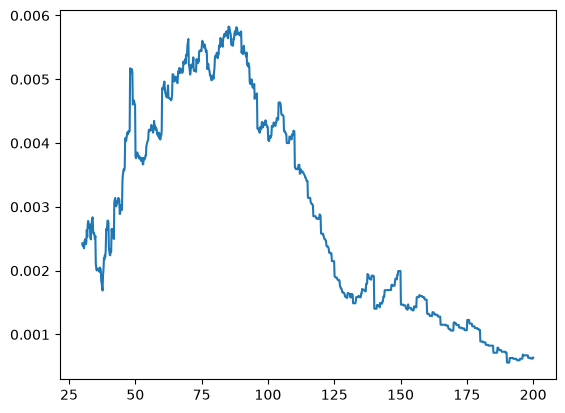

In [37]:
th_space=np.linspace(30,200,1000)
en_space=[objectivefunc_entropy(xi,var_interest)[0] for xi in th_space]
plt.clf()
plt.plot(th_space,en_space)
plt.show()

The threshold value of income that maximizes the information gain (drop in entropy) is $104.34k. Therefore, this is the value that helps us best distinguish between applicates who are likely to default and those who are not.

## Decision tree

A decision tree routine automates these steps:
1. It first identifies which variable (binary or continuous -- optimized as above) generates the highest information gain and positions it at the top of the tree. This is the "first decision" to be taken.
2. Then, the algorithm searches on each branch of the tree for the most important other variable not taken into account, and so on recursively.

In [38]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz, export_text
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import roc_curve, auc, average_precision_score

We first prepare the data, separating outcome and feature variables:

In [39]:
# remove target column to create feature only dataset
X = lc_data_train.drop('loan_status',axis=1)
# store target column
y = lc_data_train['loan_status']
X.columns = ['Owns Home','Income','dti','FICO']
X.head()

,Owns Home,Income,dti,FICO
0,1,44.304,18.47,690
1,0,38.500,33.73,660
2,1,54.000,19.00,660
3,1,60.000,33.98,695
4,0,39.354,10.85,685


In [40]:
y

0       0
1       0
2       0
3       0
4       0
       ..
8690    1
8691    1
8692    1
8693    1
8694    1
Name: loan_status, Length: 8695, dtype: int64

We use **DecisionTreeClasifier** to build a tree with a maximum of 4 levels, and then plot it. We only split a sample if there are at least 1000 observations, and require each "leaf" of the tree to have at least 200 observations. 

The *random state* option ensures that we always get the same answer. If the improvement of the criterion is identical for several splits, then one split has to be selected at random. 

In your view, what is the most important variable?

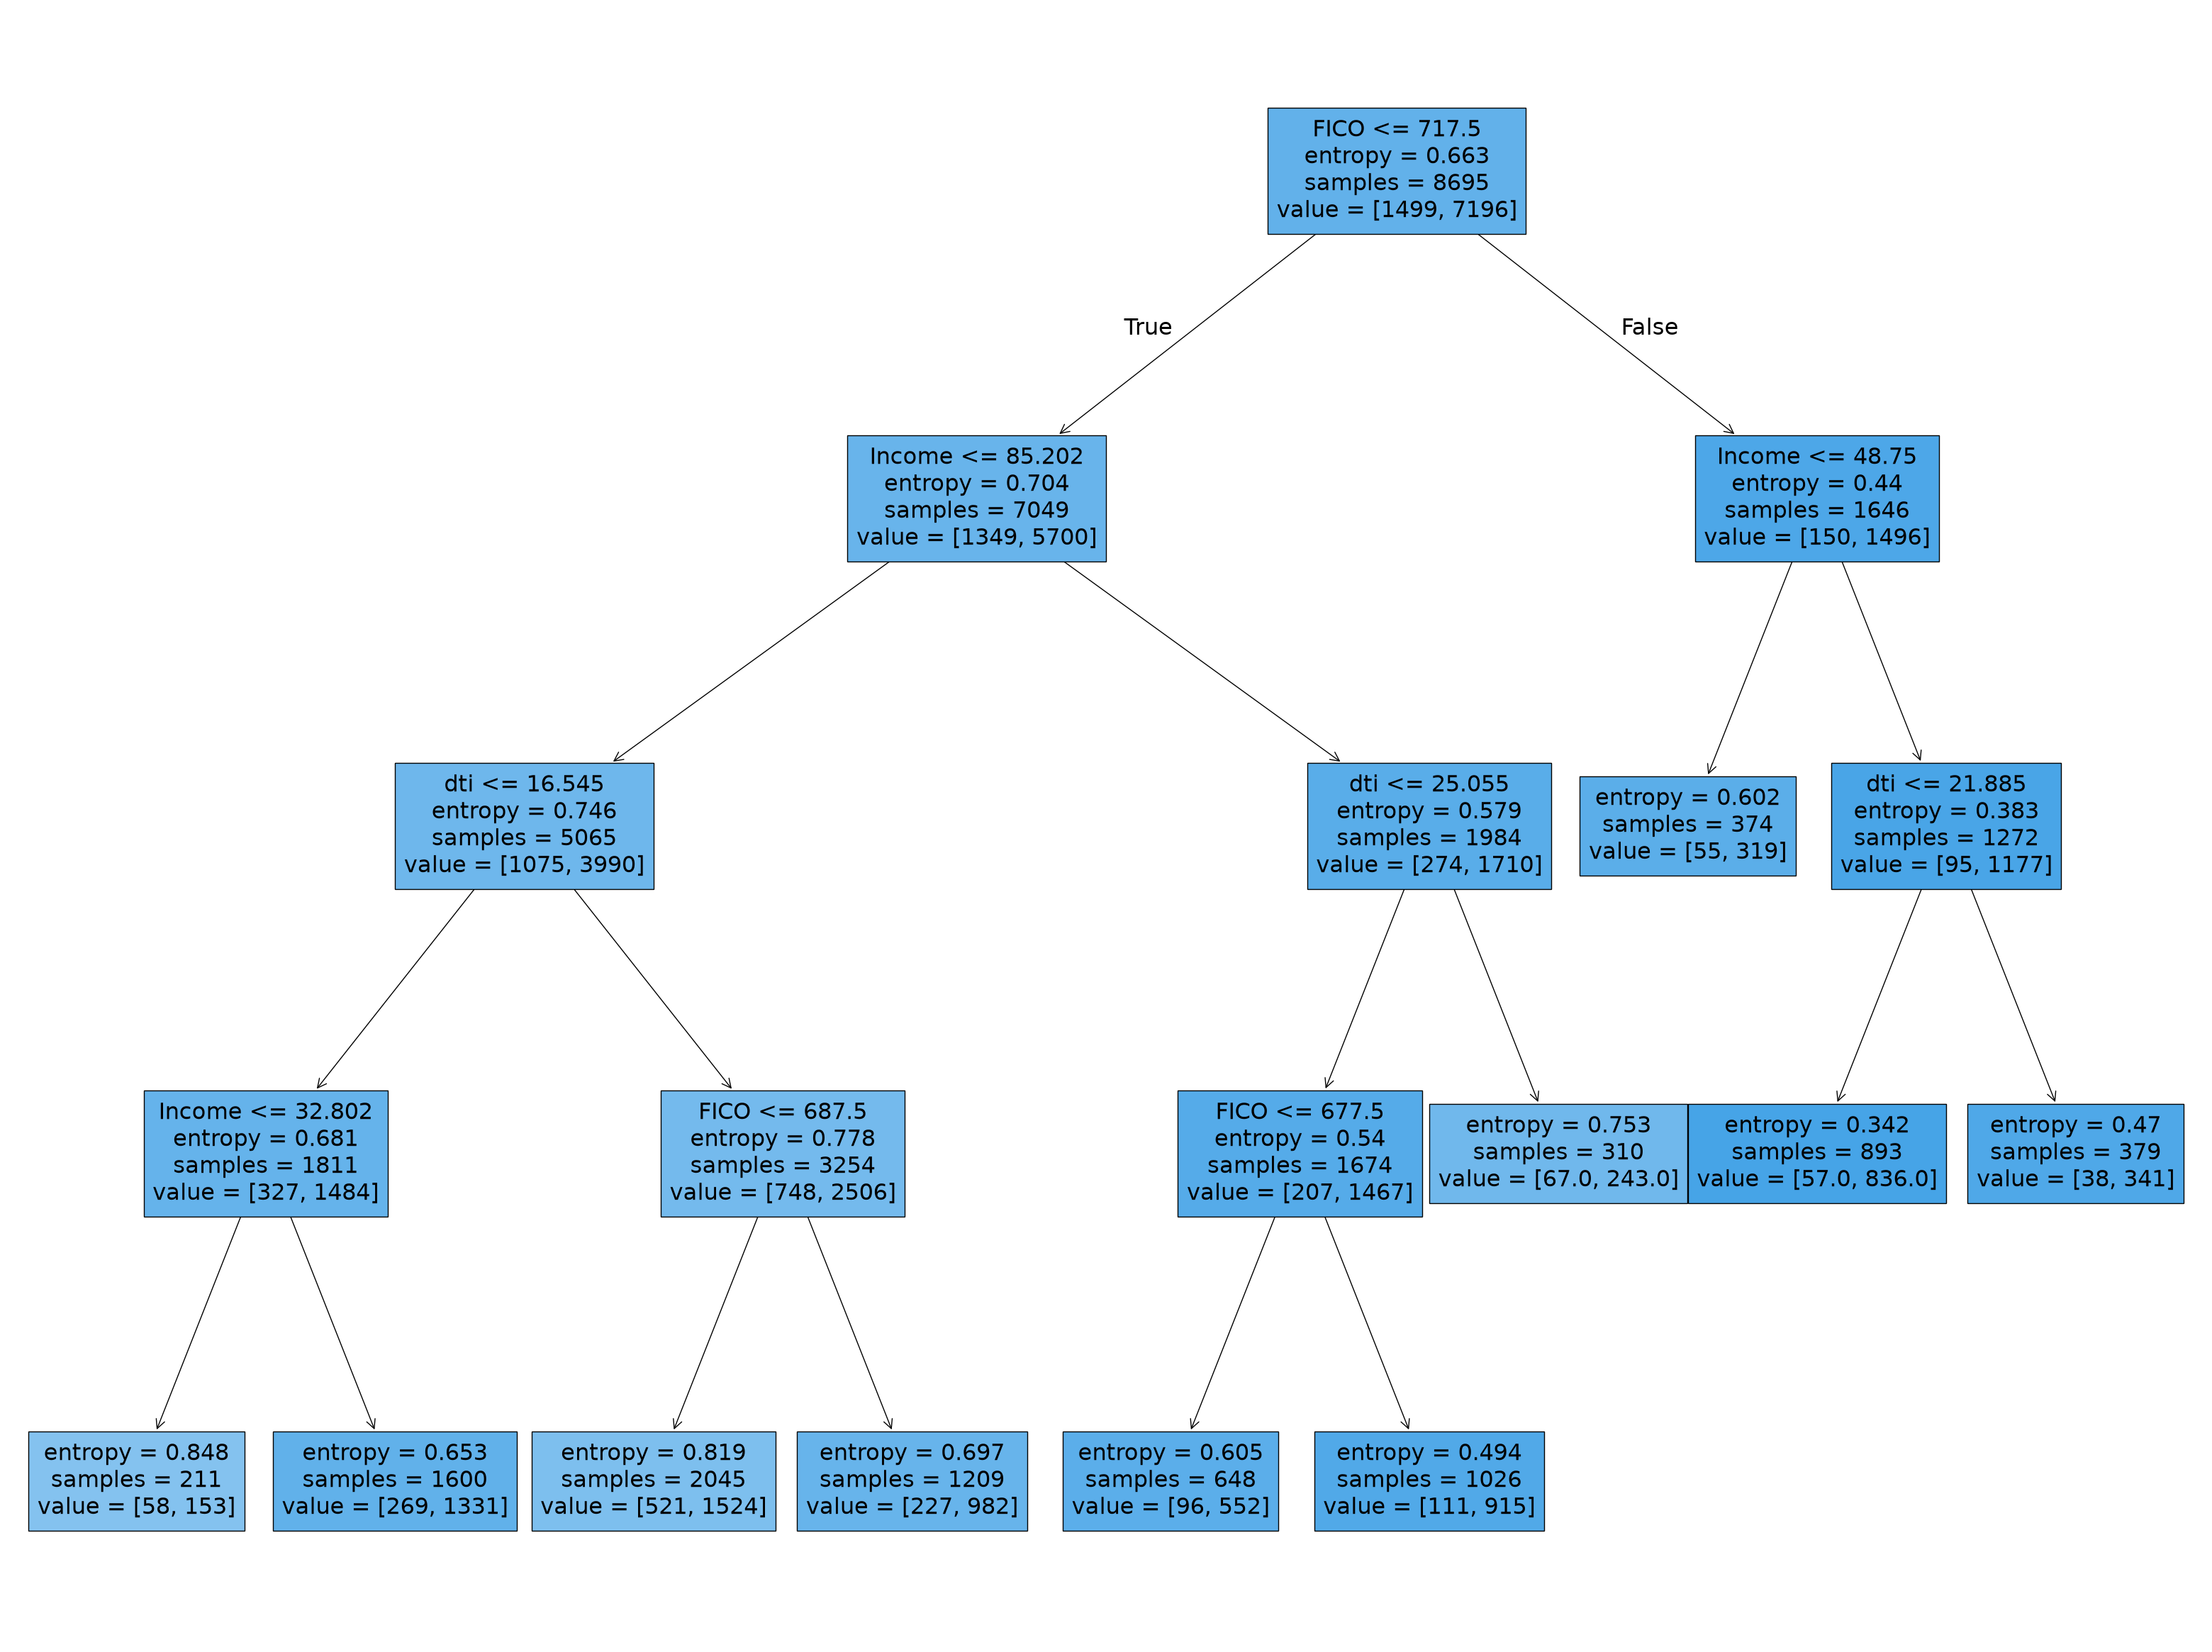

In [41]:
clf = DecisionTreeClassifier(criterion='entropy',max_depth=4,
                             min_samples_split=1000,min_samples_leaf=200,random_state=0)
clf = clf.fit(X,y)
fig, ax = plt.subplots(figsize=(40, 30))
plot_tree(clf, filled=True, feature_names=X.columns, proportion=False)
plt.show()

The numbers at the bottom correspond to a Z-value to determine if a loan is acceptable. 

For example, in the left-most leaf (FICO<717.5, Income<32.82k, debt-to-income<16.54), the successful loan probability is 153/211=72.51%.



<img src="https://github.com/mariuszoican/mgt443/blob/main/Data/DecisionTree.jpeg?raw=true" width="700px">

An examination of the figure shows that: 
1. If we set Z = 0.75: predict that all loans are good except those for which (a) income ≤ 85,202, dti > 16.545, and FICO ≤ 687.5 and (b) income ≤ 32,802, dti ≤ 16.545, and FICO ≤ 717.5. 
2. If se set Z = 0.80: Same as Z = 0.75 except that loans where FICO ≤ 717.5, income > \$85,202, and dti > 25.055 are not considered good. 

We also note that a tree can give inconsistent predictions. For example, when FICO=700, dti=10, and Income =30, the no-default probability predicted by the tree is 0.725. But when the dti value is changed from 10 to 20 (a worse value) the no-default probability increases to 0.812. 

We can also visualize the tree in "textual form:"

In [42]:
r = export_text(clf,feature_names=['Owns Home','Income','dti','FICO'])
print(r)

|--- FICO <= 717.50
|   |--- Income <= 85.20
|   |   |--- dti <= 16.55
|   |   |   |--- Income <= 32.80
|   |   |   |   |--- class: 1
|   |   |   |--- Income >  32.80
|   |   |   |   |--- class: 1
|   |   |--- dti >  16.55
|   |   |   |--- FICO <= 687.50
|   |   |   |   |--- class: 1
|   |   |   |--- FICO >  687.50
|   |   |   |   |--- class: 1
|   |--- Income >  85.20
|   |   |--- dti <= 25.05
|   |   |   |--- FICO <= 677.50
|   |   |   |   |--- class: 1
|   |   |   |--- FICO >  677.50
|   |   |   |   |--- class: 1
|   |   |--- dti >  25.05
|   |   |   |--- class: 1
|--- FICO >  717.50
|   |--- Income <= 48.75
|   |   |--- class: 1
|   |--- Income >  48.75
|   |   |--- dti <= 21.88
|   |   |   |--- class: 1
|   |   |--- dti >  21.88
|   |   |   |--- class: 1



### Prediction on test data

As in the previous lecture, we turn now to predict loan default or success on previously unseen test data

In [43]:
test = read_excel('https://github.com/mariuszoican/mgt443/blob/main/Data/lendingclub_testdata.xlsx?raw=true')
# 1 = good, 0 = default
test.head()

,home_ownership,income,dti,fico_low,loan_status
0,1,127.0,10.94,675,0
1,1,197.0,15.64,710,0
2,1,25.5,28.75,670,0
3,1,80.0,20.16,660,0
4,0,57.0,30.60,675,0


In [44]:
# remove target column to create feature only dataset
X_test = test.drop('loan_status',axis=1)
X_test.columns = ['Owns Home','Income','dti','FICO']
# store target column
y_test = test['loan_status']
y_pred = clf.predict(X_test)
y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(5916,))

If we set the default $Z=0.5$, then all loans are predicted as good! As in the previous lecture, we must search for an appropriate value for $Z$. Remember the confusion matrix and the Receiver Operating Characteristic (ROC) curve from the logistic regression. We will use the same concepts here.

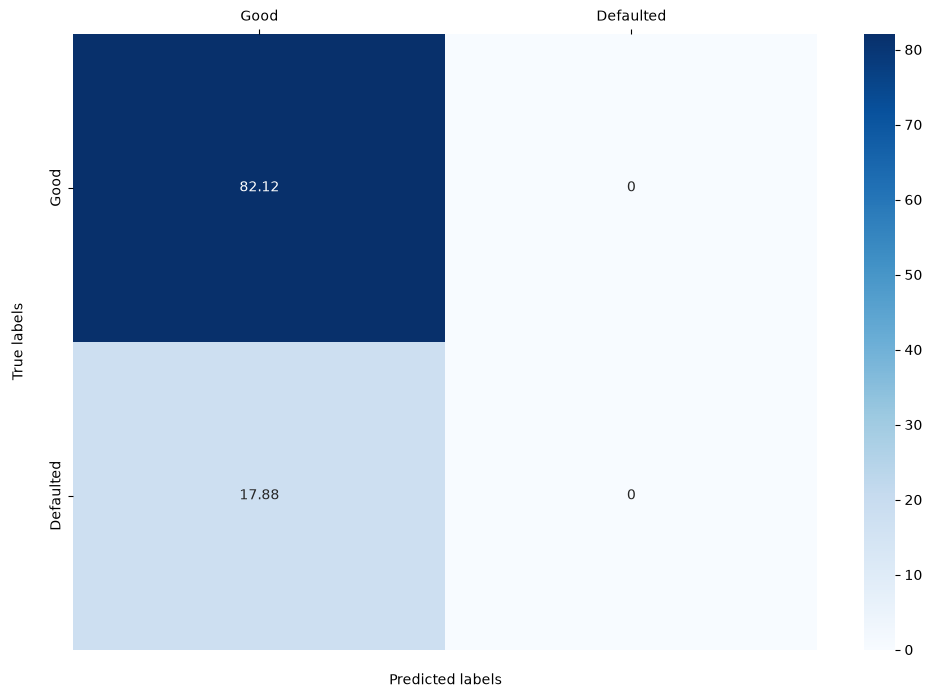

In [45]:
n_test = len(y_test)
cm = (confusion_matrix(y_test,y_pred,labels=[1, 0], sample_weight=None)/n_test)*100
plt.figure(figsize=(12, 8))      # format the plot size
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax = ax, fmt='.4g', cmap="Blues")
ax.set_xlabel('\nPredicted labels'); ax.set_ylabel('True labels\n')
ax.xaxis.tick_top()
ax.yaxis.set_ticklabels(['Good','Defaulted'],verticalalignment='center')
ax.xaxis.set_ticklabels(['Good','Defaulted'])
plt.show()

In [46]:
Q = clf.predict_proba(X_test)[:,1]
Q

array([0.85185185, 0.89181287, 0.74523227, ..., 0.74523227, 0.831875  ,
       0.74523227], shape=(5916,))

In [47]:
test

,home_ownership,income,dti,fico_low,loan_status
0,1,127.0,10.94,675,0
1,1,197.0,15.64,710,0
2,1,25.5,28.75,670,0
3,1,80.0,20.16,660,0
4,0,57.0,30.60,675,0
...,...,...,...,...,...
5911,0,50.5,28.15,670,1
5912,1,49.8,7.62,670,1
5913,0,43.0,20.40,670,1
5914,1,44.4,10.59,695,1


In [48]:
# potential values for Z (threshold probability)
Z_values = [0.5, .75, .80, .85]

#  DataFrame to store model evaluation metrics
results = DataFrame(columns=["THRESHOLD", "accuracy", "recall", "tnr", 'tpr', "fpr", "precision", "f1_score"]) 

# threshold column
results['THRESHOLD'] = Z_values  
Q = clf.predict_proba(X_test)[:,1]

n_test = len(y_test)
             
j = 0     

# iterate over each threshold    
for i in Z_values:                                                                                       
    
     # fit data to model
    preds = np.where(Q>i, 1, 0)     
    
    # confusion matrix (in percentage)
    cm = (confusion_matrix(y_test, preds,labels=[1, 0], sample_weight=None) / n_test )*100                   
    
    print('Confusion matrix for threshold =',i)
    print(cm)
    print(' ')      
    
    # True Positives
    TP = cm[0][0]   
    # False Negatives
    FN = cm[0][1]    
    # False Positives
    FP = cm[1][0]    
    # True Negatives
    TN = cm[1][1]                                                                                       
    
    results.iloc[j,1] = accuracy_score(y_test, preds) 
    results.iloc[j,2] = recall_score(y_test, preds)
    results.iloc[j,3] = TN/(FP+TN) 
    results.iloc[j,4] = TP/(FN+TP) 
    results.iloc[j,5] = FP/(FP+TN)                                                                         
    results.iloc[j,6] = precision_score(y_test, preds)
    results.iloc[j,7] = f1_score(y_test, preds)
   
   
    j += 1

Confusion matrix for threshold = 0.5
[[82.11629479  0.        ]
 [17.88370521  0.        ]]
 
Confusion matrix for threshold = 0.75
[[62.42393509 19.6923597 ]
 [11.07167005  6.81203516]]
 
Confusion matrix for threshold = 0.8
[[59.46585531 22.65043949]
 [10.44624746  7.43745774]]
 
Confusion matrix for threshold = 0.85
[[32.15010142 49.96619337]
 [ 4.73292765 13.15077755]]
 


In [49]:
print('ALL METRICS')
print( results.T)

ALL METRICS
                  0         1         2         3
THRESHOLD       0.5      0.75       0.8      0.85
accuracy   0.821163   0.69236  0.669033  0.453009
recall          1.0  0.760189  0.724166  0.391519
tnr             0.0  0.380907  0.415879   0.73535
tpr             1.0  0.760189  0.724166  0.391519
fpr             1.0  0.619093  0.584121   0.26465
precision  0.821163  0.849356   0.85058  0.871677
f1_score   0.901801  0.802303  0.782299  0.540341


### Computing the ROC curve to assess predictive power of the decision tree model

In [50]:
# Compute the ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, Q)
roc_auc = auc(fpr,tpr)

In [51]:
roc_auc

0.5948352881571994

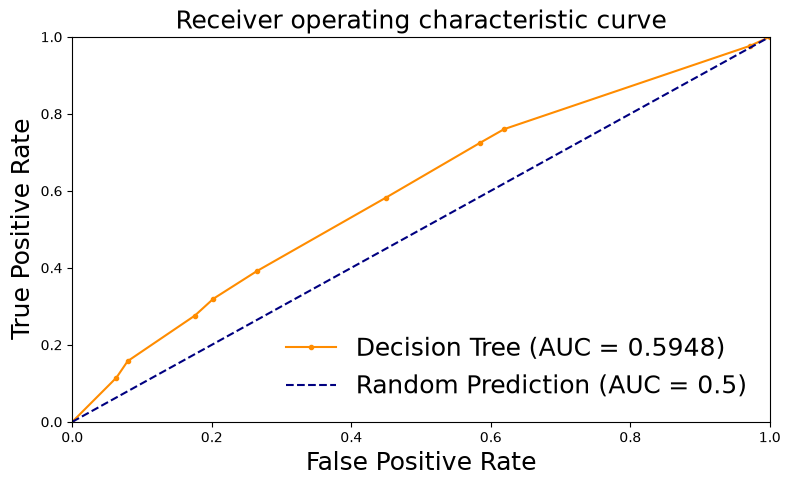

In [52]:
plt.figure(figsize=(9,5))     # format the plot size
lw = 1.5
plt.plot(fpr, tpr, color='darkorange', marker='.',
         lw=lw, label='Decision Tree (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--',
         label='Random Prediction (AUC = 0.5)' )
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate',fontsize=18)
plt.ylabel('True Positive Rate',fontsize=18)
plt.title('Receiver operating characteristic curve',fontsize=18)
plt.legend(loc="lower right",fontsize=18,frameon=False)
plt.show()